In [1]:
import yaml
import numpy as np
import polars as pl
import polars.selectors as cs
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

# Correlation across all genes

In [2]:
# Subset Olink RVAT significant

# olink_burden_test_file = "proteomics_prs_am_loftee_mac20_burden_regression_results.parquet"
olink_burden_test_file = "proteomics_prs_loftee_mac20_burden_regression_results.parquet"
# olink_burden_test_file = "proteomics_prs_df_loftee_mac20_burden_regression_results.parquet"
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/olink/blacklist/{olink_burden_test_file} -o /home/dnanexus/data_dir/

olink_whitelist = (
    pl.read_parquet(f'/home/dnanexus/data_dir/{olink_burden_test_file}')
    .rename({'gene': 'region'})
    .filter((pl.col('padj')<=0.05) & (pl.col('wilcox_padj')<=0.05) )
    .select(['region'])
    .with_columns(
        phenotype = pl.col('region') + '_olink'
    )
)

olink_correlations_file = "olink_all_mac20_lofteeHC_correlations.parquet"
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/{olink_correlations_file} -o /home/dnanexus/data_dir/

olink_corrs = (
    pl.read_parquet(f'/home/dnanexus/data_dir/{olink_correlations_file}')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .drop_nans()
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

olink_whitelist = (
    olink_whitelist
    .join(olink_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    # .sort('loftee_corr_abs', descending=True)
    # .sort('pval_fdr')
    # .unique(subset=["region"], keep="first", maintain_order=True)
)

olink_whitelist

Error: path "/home/dnanexus/data_dir/proteomics_prs_loftee_mac20_burden_regres
sion_results.parquet" already exists but -f/--overwrite was not set
Error: path
"/home/dnanexus/data_dir/olink_all_mac20_lofteeHC_correlations.parquet"
already exists but -f/--overwrite was not set


region,phenotype,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64
"""ENSG00000163606""","""ENSG00000163606_olink""",0.204082,0.204082,1.0
"""ENSG00000144857""","""ENSG00000144857_olink""",0.162616,0.162616,1.0
"""ENSG00000161270""","""ENSG00000161270_olink""",0.175562,0.175562,1.0
"""ENSG00000091129""","""ENSG00000091129_olink""",0.165924,0.165924,1.0
"""ENSG00000132437""","""ENSG00000132437_olink""",0.214824,0.214824,1.0
…,…,…,…,…
"""ENSG00000101160""","""ENSG00000101160_olink""",0.386419,0.386419,1.0
"""ENSG00000130528""","""ENSG00000130528_olink""",0.305544,0.305544,1.0
"""ENSG00000110448""","""ENSG00000110448_olink""",0.337765,0.337765,1.0


In [3]:
# Configuration and paths
mac = 20
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

abs_phenotypes = True

# Load annotation configuration
if abs_phenotypes:
    config_path = "/home/dnanexus/ukbgym/config_wgs.yaml" # If abs_pheno then deleteriousness direction
else:    
    config_path = "/home/dnanexus/ukbgym/config_olink.yaml"

with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof""","""loftee_hc""","""#E31A1C""","""LOFTEE HC""",1
"""plof_consequences""","""consequence_frameshift_variant""","""#E31A1C""","""VEP Frameshift""",1
"""plof_consequences""","""consequence_stop_gained""","""#FB9A99""","""VEP Stop Gained""",1
"""plof_consequences""","""consequence_splice_donor_varia…","""#6A1B9A""","""VEP Splice Donor""",1
"""plof_consequences""","""consequence_splice_acceptor_va…","""#AB47BC""","""VEP Splice Acceptor""",1
…,…,…,…,…
"""vep_consequences""","""consequence_start_lost""","""#E65100""","""VEP Start Lost""",1
"""vep_consequences""","""consequence_stop_lost""","""#FFB300""","""VEP Stop Lost""",1
"""vep_consequences""","""consequence_missense_variant""","""#1E90FF""","""VEP Missense""",1


In [4]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

# ANNO_FILE = "annotations_fillna_ukbgym.parquet"
ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")

min_range = -2000
max_range = +0

anno = (
    anno
    .filter(
        # Olink whitelist
        (pl.col('region').is_in(olink_whitelist['region'].unique())) &

        # Choose Gene Body
        # ((pl.col('consequence_upstream_gene_variant') == False) & (pl.col('consequence_downstream_gene_variant') == False)) &
        
        # Choose CDS
        # (pl.col('vep_cds_relaxed')==True) &

        # Choose non CDS only
        # ((pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)) &

        # Choose VEP consequence
        (pl.col('consequence_missense_variant') == True) &
        # (pl.col('consequence_synonymous_variant') == True) &
        # (pl.col('consequence_5_prime_utr_variant') == True) &
        # (pl.col('consequence_upstream_gene_variant') == True) &
        # (pl.col('consequence_downstream_gene_variant') == True) &
        # (pl.col('consequence_intron_variant') == True) &

        # Choose MobiDB region
        # (pl.col('mobi_lip_full') == True) &
        # (pl.col('mobi_disorder_full') == True) &

        # Custom variant class filter
        # filter_expression &

        # Choose regulatory region
        # (pl.col('encode_eh_pr') == True) &
        # (pl.col('encode_all_tf') == True) &
        
        # Proximity to TSS
        # (pl.col('dist_to_tss') >= min_range) &
        # (pl.col('dist_to_tss') <= max_range) &

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    # .with_columns(
    #     core_promoter = pl.col('dist_to_tss').abs() <= 50,
    #     encode_annotated = pl.col('not_in_encode') == False,
    #     encode_eh_pr = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pls', 'encode_pels', 'encode_dels']),
    #     encode_all_tf = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_tf', 'encode_ca_tf']),
    # )
)

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

anno = (
    anno
    .select(
        # set(['id', 'region', 'tss', 'strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
        set(['id', 'region']).union(set(existing_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
)

anno

Error: path
"/home/dnanexus/data_dir/annotations_fillna_ukbgym_with_mane.parquet" already
exists but -f/--overwrite was not set


/tmp/ipykernel_53481/3511879965.py:62: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
/tmp/ipykernel_53481/3511879965.py:70: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


low_complexity_domain,abexp_abs_max,relative_cds_position,encode_tf,loftee_lc,consequence_missense_variant,esmscoremissense,am_pathogenicity,consequence_synonymous_variant,absplice2_max,five_prime_utr_variant_consequence_uaug_lost,encode_dels,consequence_frameshift_variant,ted_domain,encode_pels,cadd_raw,consequence_splice_acceptor_variant,mobi_lip_full,promoterai,five_prime_utr_variant_consequence_ustop_gained,consequence_stop_lost,gpn_score,verphylop,encode_pls,region,consequence_stop_gained,delta_score,pangolin_score,loftee_hc,score_pai3d,id,five_prime_utr_variant_consequence_uaug_gained,consequence_start_lost,five_prime_utr_variant_consequence_ustop_lost,consequence_splice_donor_variant,mobi_curated_disorder_priority
bool,f32,f32,bool,i8,i8,f32,f32,i8,f32,u8,bool,i8,bool,bool,f32,i8,bool,f32,u8,i8,f32,f32,bool,str,i8,f32,f32,i8,f32,str,u8,i8,u8,i8,bool
false,0.04636,0.23,false,0,1,-3.026,0.0925,0,0.000341,0,false,0,false,false,1.51633,0,true,0.0,0,0,-5.96,3.853,false,"""ENSG00000054938""",0,0.0,0.0,0,0.412258,"""chr11:74710982:G:C""",0,0,0,0,false
false,0.06054,0.45,false,0,1,-4.609,0.0883,0,0.000321,0,false,0,true,false,3.457253,0,false,0.0,0,0,-9.21,11.295,false,"""ENSG00000033170""",0,0.0,0.0,0,0.0,"""chr14:65669429:G:A""",0,0,0,0,false
false,0.03079,0.25,false,0,1,-3.17,0.0808,0,0.000321,0,false,0,true,false,-0.314408,0,false,0.0,0,0,-3.57,-0.874,false,"""ENSG00000099994""",0,0.02,0.0,0,0.223731,"""chr22:24184785:G:T""",0,0,0,0,false
false,0.069513,0.32,false,0,1,-5.596,0.9023,0,0.000278,0,true,0,false,false,4.471949,0,false,0.0,0,0,-8.82,5.12,false,"""ENSG00000136011""",0,0.0,0.0,0,0.797299,"""chr12:103674023:T:A""",0,0,0,0,false
false,0.083404,0.28,false,0,1,-4.027,0.0,0,0.000342,0,false,0,false,false,3.670366,0,true,0.022,0,0,-12.3,7.183,false,"""ENSG00000155657""",0,0.01,0.0,0,0.0,"""chr2:178702210:C:G""",0,0,0,0,true
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
false,0.091039,0.87,false,0,1,-6.868,0.0955,0,0.002033,0,false,0,true,false,3.712089,0,false,0.0,0,0,-3.78,1.974,false,"""ENSG00000180210""",0,0.03,0.01,0,0.500868,"""chr11:46729535:G:A""",0,0,0,0,false
false,0.059004,0.22,false,0,1,-3.527,0.0767,0,0.000321,0,true,0,false,false,1.229156,0,false,0.0,0,0,-4.6,2.427,false,"""ENSG00000186340""",0,0.0,0.0,0,0.0,"""chr6:169241865:G:A""",0,0,0,0,false
false,0.06996,0.29,false,0,1,-2.676,0.0973,0,0.000371,0,false,0,false,false,3.547132,0,false,0.0,0,0,-5.1,2.528,false,"""ENSG00000110799""",0,0.0,0.0,0,0.342707,"""chr12:6036457:C:T""",0,0,0,0,false


In [12]:
# selected_categories = ['missense', 'genetic_diversity', 'conservation', 'regulatory_nondir'] # CDS
selected_categories = ['missense', 'genetic_diversity', 'conservation'] # missense
# selected_categories = ['splicing', 'genetic_diversity', 'conservation'] # splicing
# selected_categories = ['genetic_diversity', 'conservation', 'naive']    # plof comparison
# selected_categories = ['genetic_diversity', 'splicing', 'conservation', 'regulatory', 'regulatory_nondir'] # non coding
# selected_categories = ['genetic_diversity', 'splicing', 'conservation'] # introns

selected_annos = anno_config_df.filter(
    pl.col('category').is_in(selected_categories)
)['annotation'].to_list()

melted_anno = (
    anno
    
    .select(
        set(['id', 'region']).union(set(selected_annos))
    )

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    ).with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )
)
melted_anno

id,region,annotation,annotation_score
str,str,str,f32
"""chr11:74710982:G:C""","""ENSG00000054938""","""cadd_raw""",1.51633
"""chr14:65669429:G:A""","""ENSG00000033170""","""cadd_raw""",3.457253
"""chr22:24184785:G:T""","""ENSG00000099994""","""cadd_raw""",-0.314408
"""chr12:103674023:T:A""","""ENSG00000136011""","""cadd_raw""",4.471949
"""chr2:178702210:C:G""","""ENSG00000155657""","""cadd_raw""",3.670366
…,…,…,…
"""chr11:46729535:G:A""","""ENSG00000180210""","""verphylop""",1.974
"""chr6:169241865:G:A""","""ENSG00000186340""","""verphylop""",2.427
"""chr12:6036457:C:T""","""ENSG00000110799""","""verphylop""",2.528


In [13]:
# Read Olink phenotype data

RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus/data_dir"

# APPV_FILE = "olink_cov_pcs_prs_rint_all_genes_EURunrelated_appv_percentiles.parquet"
# APPV_FILE = "olink_protrider_prs_rint_all_genes_EURunrelated_appv_percentiles.parquet"
APPV_FILE = "cauc_protrider_lite_prs_t_df_all_genes_EURunrelated_appv_percentiles_descending.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
olink_appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

olink_appv = (
    olink_appv
    .filter(
        (pl.col('n_individuals') <= mac)
    )
    .join(
        olink_whitelist.lazy(),
        on=["region", "phenotype"],
        how="semi"
    )
    .with_columns(
        mean_pheno_value = pl.when(abs_phenotypes)
        .then(pl.col('mean_pheno_value').abs())
        .otherwise(pl.col('mean_pheno_value'))
    )
)

Error: path "/home/dnanexus/data_dir/cauc_protrider_lite_prs_t_df_all_genes_EU
Runrelated_appv_percentiles_descending.parquet" already exists but
-f/--overwrite was not set


In [14]:
# Merge phenotype data and annotation data
final_lazy_plan = (
    olink_appv
    
    .join(
        melted_anno.lazy(), 
        on="id", 
        how="inner"
    )
    .filter(
        pl.col('region') + '_olink' == pl.col('phenotype')
    )
    .with_columns(
        pl.col(c)
        .rank("max")
        .over(["region", "phenotype", "annotation"])
        .alias(f"{c}_rank")
        for c in ['mean_pheno_value', 'annotation_score']
    )
    .group_by(["region", "phenotype", "annotation"])
    .agg(
        n_variants = pl.col("id").count(),
        correlation = pl.when(
            (pl.col("annotation_score_rank").n_unique() > 1) & 
            (pl.col("mean_pheno_value_rank").n_unique() > 1)
        )
        .then(
            pl.corr("annotation_score_rank", "mean_pheno_value_rank", propagate_nans=True)
        )
        .otherwise(None) # None maps to NaN for float columns
    )

    .filter(pl.col('annotation')!='loftee_hc')
    .select(['region', 'phenotype', 'annotation', 'n_variants', 'correlation'])

    .drop_nans().drop_nulls()

    .collect(engine='streaming')
)

# --- 4. Join with beta directions and annotation directions ---
correlation_df = (
    final_lazy_plan

    .join(
        anno_config_df,
        on='annotation'
    )
    .join(
        olink_whitelist,
        on=['region', 'phenotype'],
    )
    .with_columns(
        corr_beta = pl.col('correlation')*pl.col('loftee_corr_dir')*pl.col('annotation_dir') 
    )
    .with_columns(
        corr_beta_rescaled = (pl.col('corr_beta')/pl.col('loftee_corr'))*pl.col('loftee_corr_dir')
    )
)

correlation_df

region,phenotype,annotation,n_variants,correlation,category,color,label,annotation_dir,loftee_corr,loftee_corr_abs,loftee_corr_dir,corr_beta,corr_beta_rescaled
str,str,str,u64,f64,str,str,str,i8,f64,f64,f64,f64,f64
"""ENSG00000169919""","""ENSG00000169919_olink""","""cadd_raw""",94,0.571101,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,0.245295,0.245295,1.0,0.571101,2.328222
"""ENSG00000023318""","""ENSG00000023318_olink""","""cadd_raw""",37,0.460645,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,0.183309,0.183309,1.0,0.460645,2.512943
"""ENSG00000187244""","""ENSG00000187244_olink""","""esmscoremissense""",135,-0.262678,"""missense""","""#feb72d""","""ESM1v""",-1,0.257885,0.257885,1.0,0.262678,1.018585
"""ENSG00000173714""","""ENSG00000173714_olink""","""am_pathogenicity""",128,0.347714,"""missense""","""#feb72d""","""AlphaMissense""",1,0.178374,0.178374,1.0,0.347714,1.94935
"""ENSG00000158516""","""ENSG00000158516_olink""","""gpn_score""",92,-0.220687,"""conservation""","""#942c80""","""GPN-MSA""",-1,0.320642,0.320642,1.0,0.220687,0.688266
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000087303""","""ENSG00000087303_olink""","""gpn_score""",229,-0.303312,"""conservation""","""#942c80""","""GPN-MSA""",-1,0.061965,0.061965,1.0,0.303312,4.894928
"""ENSG00000145794""","""ENSG00000145794_olink""","""cadd_raw""",210,0.272212,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,0.184545,0.184545,1.0,0.272212,1.475042
"""ENSG00000132305""","""ENSG00000132305_olink""","""esmscoremissense""",90,0.158793,"""missense""","""#feb72d""","""ESM1v""",-1,0.086613,0.086613,1.0,-0.158793,-1.833361


In [25]:
consistent_genes = (
    correlation_df
    .drop_nulls().drop_nans()
    .group_by(['region'])
    .agg(n_annotations = pl.len())
    .sort('n_annotations', descending=True)
    .filter(pl.col('n_annotations') == correlation_df['annotation'].n_unique())
)

filt_corr_df = correlation_df.join(consistent_genes, on=['region'], how='inner')
filt_corr_df = correlation_df.filter(pl.col("n_variants") > 100)
filt_corr_df.sort('corr_beta', descending=True)

region,phenotype,annotation,n_variants,correlation,category,color,label,annotation_dir,loftee_corr,loftee_corr_abs,loftee_corr_dir,corr_beta,corr_beta_rescaled
str,str,str,u64,f64,str,str,str,i8,f64,f64,f64,f64,f64
"""ENSG00000174175""","""ENSG00000174175_olink""","""am_pathogenicity""",124,0.688079,"""missense""","""#feb72d""","""AlphaMissense""",1,0.360681,0.360681,1.0,0.688079,1.907721
"""ENSG00000133805""","""ENSG00000133805_olink""","""am_pathogenicity""",127,0.682237,"""missense""","""#feb72d""","""AlphaMissense""",1,0.202751,0.202751,1.0,0.682237,3.364909
"""ENSG00000103174""","""ENSG00000103174_olink""","""score_pai3d""",125,0.66464,"""missense""","""#feb72d""","""PrimateAI-3D""",1,0.158875,0.158875,1.0,0.66464,4.183424
"""ENSG00000174175""","""ENSG00000174175_olink""","""cadd_raw""",124,0.654779,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,0.360681,0.360681,1.0,0.654779,1.815396
"""ENSG00000172009""","""ENSG00000172009_olink""","""am_pathogenicity""",159,0.654149,"""missense""","""#feb72d""","""AlphaMissense""",1,0.115661,0.115661,1.0,0.654149,5.655748
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000197586""","""ENSG00000197586_olink""","""esmscoremissense""",103,-0.494786,"""missense""","""#feb72d""","""ESM1v""",-1,-0.042751,0.042751,-1.0,-0.494786,-11.573685
"""ENSG00000197586""","""ENSG00000197586_olink""","""cadd_raw""",103,0.513652,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,-0.042751,0.042751,-1.0,-0.513652,-12.014983
"""ENSG00000197586""","""ENSG00000197586_olink""","""score_pai3d""",103,0.519691,"""missense""","""#feb72d""","""PrimateAI-3D""",1,-0.042751,0.042751,-1.0,-0.519691,-12.156254


In [26]:
# Filter to only those with sign agreement
annos_w_inconsistent_assocs = (
    filt_corr_df
    .drop_nulls().drop_nans()
    .select(['region', 'annotation'])
    .group_by('annotation')
    .agg(n_associations = pl.len())
    .select('n_associations').n_unique()
) - 1

print(f"Annotations with inconsistent associations: {annos_w_inconsistent_assocs}")

# Check if the variant counts are consistent within each (region, phenotype) pair
var_inconsistent = (
    filt_corr_df
    .drop_nans()
    .drop_nulls()
    .group_by(["region"])
    .agg(pl.col("n_variants").n_unique().alias("n_variants_unique"))
    .filter(pl.col("n_variants_unique") > 1)
)
print(f"Inconsistent (region, phenotype) pairs: {var_inconsistent.shape[0]}")

Annotations with inconsistent associations: 2
Inconsistent (region, phenotype) pairs: 0


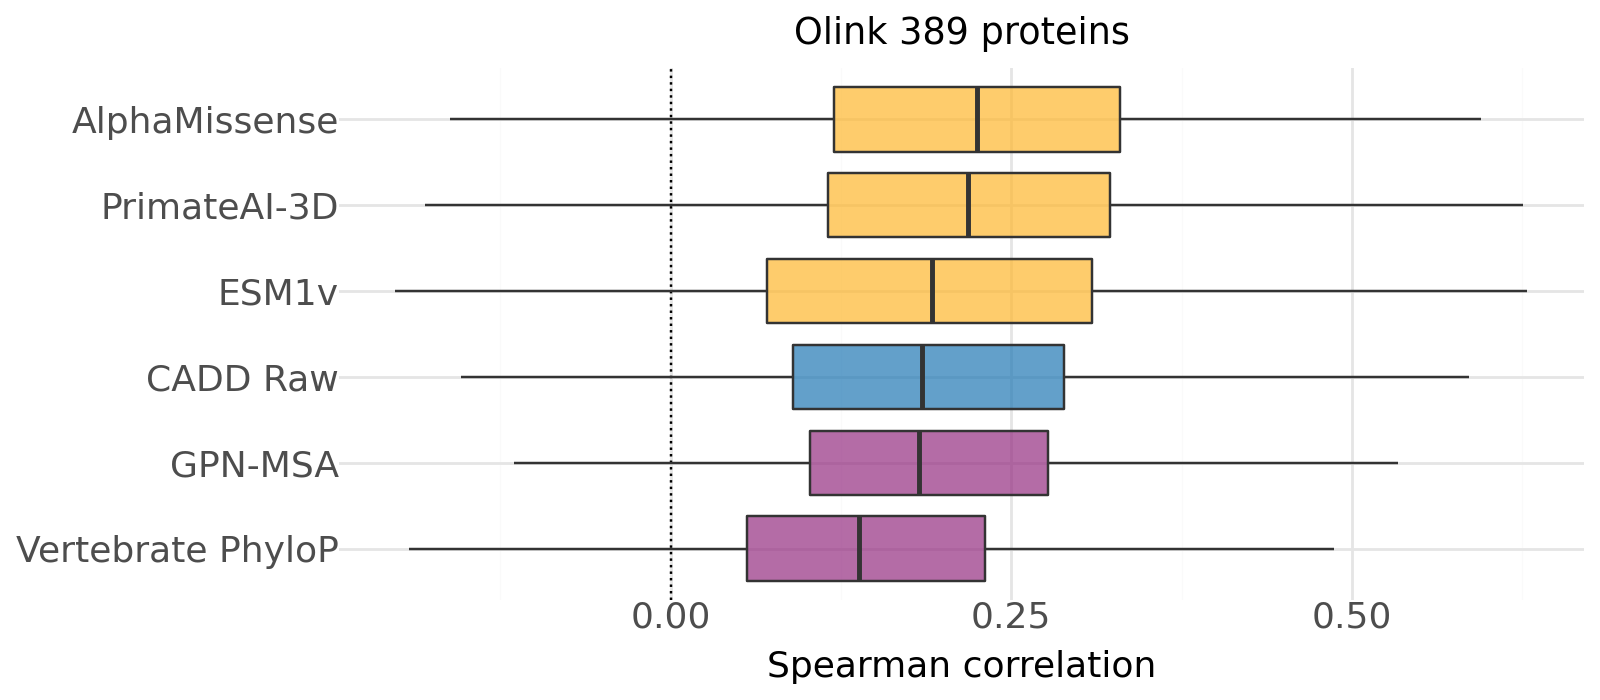

In [27]:
plotting_col = 'corr_beta'
dashed_line_value = 1 if 'rescaled' in plotting_col else 0

# Calculate medians and join back
corr_pl = (
    filt_corr_df
    .drop_nans()
    .with_columns(
        median_corr_beta = pl.col(plotting_col).median().over("annotation")
    )
)

# 2. Determine the categorical order for the labels
ordered_labels = (
    corr_pl
    .sort("median_corr_beta", descending=False)
    .select("label")
    .unique(maintain_order=True)
    .to_series()
)

# 3. Apply the ordering using pl.Enum
corr_pl = corr_pl.with_columns(pl.col("label").cast(pl.Enum(ordered_labels)))

# 4. Create the color dictionary (Polars style)
color_dict = dict(corr_pl.select("annotation", "color").unique().iter_rows())

# Plot
(
    ggplot(corr_pl, aes(x="label", y=plotting_col, fill="annotation"))
    + geom_hline(aes(yintercept=dashed_line_value), color='black', linetype='dotted')
    + geom_boxplot(alpha=0.7, outlier_shape=None)
    # + geom_boxplot(alpha=0.7)
    + theme_minimal()
    + scale_fill_manual(values=color_dict)
    + labs(
        x="",
        y="Spearman correlation",
        title=f"Olink {len(corr_pl['region'].unique())} proteins"
            # \nmissense variants"
            # \nGene body ±5kb"
            # \nTSS [{min_range}bp, {max_range}bp]"
            # \nsplice donor/acceptor variants"
    )
    + coord_flip()
    + theme(
        figure_size=(8, corr_pl['annotation'].n_unique()/2 + 0.5),
        legend_position="none",
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [28]:
import itertools
from scipy.stats import wilcoxon

annotations = filt_corr_df.select(pl.col("annotation")).unique().to_series().to_list()
pairs = list(itertools.combinations(annotations, 2))

results = []
for a, b in pairs:
    # Subset to same gene-trait pairs where both VSMs have values
    df_a = filt_corr_df.filter(pl.col("annotation") == a).select(["region", "corr_beta"])
    df_b = filt_corr_df.filter(pl.col("annotation") == b).select(["region", "corr_beta"])

    merged = df_a.join(df_b, on=["region"], how="inner", suffix="_b")

    if merged.height > 0:
        stat, pval = wilcoxon(merged["corr_beta"].to_numpy(), merged["corr_beta_b"].to_numpy(), alternative="two-sided")
        results.append((a, b, merged.height, stat, pval))

# Make results dataframe
stats_df = pl.DataFrame(
    results,
    schema=["VSM_A", "VSM_B", "N_pairs", "W_stat", "pval_raw"]
)

stats_df.filter(pl.col("pval_raw") < 0.05).sort("pval_raw")
# stats_df.sort("pval_raw")

/tmp/ipykernel_53481/863415217.py:20: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.


VSM_A,VSM_B,N_pairs,W_stat,pval_raw
str,str,i64,f64,f64
"""verphylop""","""am_pathogenicity""",375,9394.0,8.0605e-35
"""verphylop""","""cadd_raw""",389,12033.0,1.8336e-31
"""verphylop""","""score_pai3d""",297,5697.0,1.3816e-28
"""verphylop""","""gpn_score""",389,14153.0,8.7742e-27
"""am_pathogenicity""","""gpn_score""",375,16959.0,3.0955e-18
…,…,…,…,…
"""esmscoremissense""","""am_pathogenicity""",375,18854.0,5.9154e-15
"""score_pai3d""","""cadd_raw""",297,11333.0,3.1795e-13
"""esmscoremissense""","""verphylop""",389,21999.0,7.0728e-13
